In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [8]:

# Activation functions and their gradients
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_gradient(x):
    return sigmoid(x) * (1 - sigmoid(x))

def tanh(x):
    return np.tanh(x)

def tanh_gradient(x):
    return 1 - np.tanh(x)**2

def relu(x):
    return np.maximum(x,0)

def relu_gradient(x):
    return x>0

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_gradient(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)

def linear(x):
    return x

def linear_gradient(x):
    return np.ones_like(x)

# Weight initialization functions
def zero_init(shape):
    return np.zeros(shape)

def random_init(shape):
    return np.random.rand(*shape)-0.5

def normal_init(shape):
    return np.random.normal(0, 1, shape)

In [9]:
# ... (previous code remains the same)
from sklearn.metrics import accuracy_score
class NeuralNetwork:
    def __init__(self, N, layer_sizes, lr, activation, weight_init, num_epochs, batch_size,der_activation):
        self.N = N
        self.layer_sizes = layer_sizes
        self.lr = lr
        self.activation = activation
        self.weight_init = weight_init
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.weights = []
        self.biases = []
        self.der_activation=der_activation
        for i in range(N - 1):
            input_size = layer_sizes[i]
            output_size = layer_sizes[i + 1]
            self.weights.append(weight_init((output_size,input_size)))
            self.biases.append(np.zeros((output_size,1)))

    
    def forward(self, X):
        self.layer_outputs = []
        self.layer_dots=[]
        z=X
        for i in range(self.N - 2):
            f = np.dot(self.weights[i],z) + self.biases[i]
            self.layer_dots.append(f)
            z = self.activation(f)
            self.layer_outputs.append(z)
        
        self.layer_dots.append(np.dot(self.weights[-1],z) + self.biases[-1])
        output = self.softmax(np.dot(self.weights[-1],z) + self.biases[-1])
        self.layer_outputs.append(output)
        return output

    def softmax(self,x):
        x=x.T
        max_x = np.amax(x, 1).reshape(x.shape[0],1) # Get the row-wise maximum
        e_x = np.exp(x - max_x ) # For stability
        return (e_x / e_x.sum(axis=1, keepdims=True)).T
    
    def one_hot(self,Y):
        one_hot_Y = np.zeros((Y.size, Y.max() + 1))
        one_hot_Y[np.arange(Y.size), Y] = 1
        one_hot_Y = one_hot_Y.T
        return one_hot_Y
    
    def backward(self, X, Y,probabilities):
        m = X.shape[1]
        one_hot_Y = self.one_hot(Y)
        # print(m,X.shape,Y.shape,"yes")

        gradients = []

        # Backward pass to compute gradients
        dZ = probabilities - one_hot_Y
        dw = 1/m*np.dot(dZ, self.layer_outputs[-2].T) 
        db = 1/m*np.sum(dZ)
        gradients.insert(0,(dw,db))

        for i in range(self.N - 3, 0, -1):
            dZ = np.dot(self.weights[i+1].T,dZ) * self.der_activation(self.layer_dots[i])
            dW = np.dot(dZ,self.layer_outputs[i-1].T) / m
            db = np.sum(dZ) / m
            gradients.insert(0, (dW, db))
        
        i=0
        dZ = np.dot(self.weights[i+1].T,dZ) * self.der_activation(self.layer_dots[i])
        dW = np.dot(dZ,X.T) / m
        db = np.sum(dZ) / m
        gradients.insert(0, (dW, db))
        return gradients

    def update_params(self, gradients):
        for i in range(self.N - 1):
            self.weights[i] -= self.lr * gradients[i][0]
            self.biases[i] -= self.lr * gradients[i][1]

    def cross_entropy_loss(self, predictions, targets):
        targets=self.one_hot(targets)
        epsilon = 1e-9
        num_samples = targets.shape[1]
        loss = -np.sum(targets * np.log(predictions+epsilon)) / num_samples
        return loss
    
    def fit(self, X, Y, X_valid=None, Y_valid=None):
        train_losses = []
        valid_losses = []
        n=X.shape[1]
        for epoch in range(self.num_epochs):
            for i in range(0, n, self.batch_size):
                X_batch = X.T[i:i + self.batch_size]
                Y_batch = Y.T[i:i + self.batch_size]
                X_batch=X_batch.T
                Y_batch=Y_batch
                
                # Forward and backward pass
                probs = self.forward(X_batch)
                # break
                gradients = self.backward(X_batch, Y_batch,probs)
                self.update_params(gradients)

            # Evaluate on the validation set
            if X_valid is not None and Y_valid is not None:
                probs1= self.forward(X_valid)
                valid_loss=self.cross_entropy_loss(probs1,Y_valid)
                valid_losses.append(valid_loss)

            probabilities = self.forward(X)
            train_loss=self.cross_entropy_loss(probabilities,Y)
            train_losses.append(train_loss)
            print(f"Epoch {epoch + 1}/{self.num_epochs}, Train Loss: {train_loss} Validation loss: {valid_loss}")

        # Plot training and validation loss
        plt.plot(range(1, self.num_epochs + 1), train_losses, label='Training Loss')
        if X_valid is not None and Y_valid is not None:
            plt.plot(range(1, self.num_epochs + 1), valid_losses, label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()
    
    def predict_proba(self, X):
        scores = self.forward(X)
        return scores

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, 0)

    def score(self, X, Y):
        predictions = self.predict(X)
        accuracy = np.sum(predictions == Y) / Y.size
        return accuracy

# model.gradient_descent(X_train, Y_train, 0.1, 500)
                               


Training model with sigmoid activation function...
Epoch 1/30, Train Loss: 2.4749851543656054 Validation loss: 2.4644261552455373
Epoch 2/30, Train Loss: 2.4047920867309482 Validation loss: 2.3970725925183882
Epoch 3/30, Train Loss: 2.365576596195227 Validation loss: 2.3598085238758015
Epoch 4/30, Train Loss: 2.3414046777130375 Validation loss: 2.3370601013589374
Epoch 5/30, Train Loss: 2.325687636464833 Validation loss: 2.3224176870789477
Epoch 6/30, Train Loss: 2.3150988519504674 Validation loss: 2.3126573075514147
Epoch 7/30, Train Loss: 2.3077464093694187 Validation loss: 2.3059521330054062
Epoch 8/30, Train Loss: 2.302479865710847 Validation loss: 2.301195993968282
Epoch 9/30, Train Loss: 2.298573810751217 Validation loss: 2.2976950822313467
Epoch 10/30, Train Loss: 2.295561787659919 Validation loss: 2.2950062453288176
Epoch 11/30, Train Loss: 2.293140475141995 Validation loss: 2.2928437310310263
Epoch 12/30, Train Loss: 2.2911111571999174 Validation loss: 2.29102227169872
Epoch 1

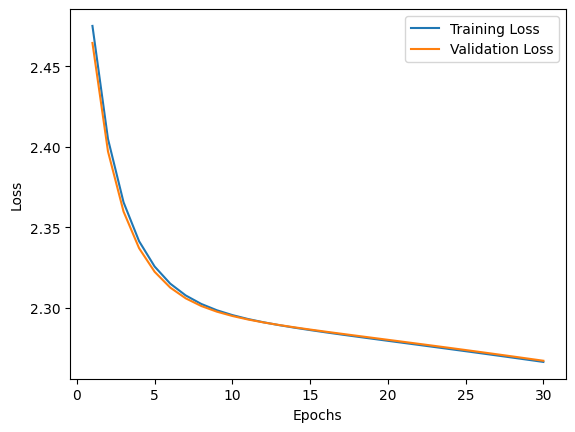

Test Accuracy (sigmoid): 0.2306
Training model with tanh activation function...
Epoch 1/30, Train Loss: 2.6561892131514786 Validation loss: 2.6405525271687322
Epoch 2/30, Train Loss: 2.5000199419811437 Validation loss: 2.486627123876661
Epoch 3/30, Train Loss: 2.367027117907379 Validation loss: 2.355624261482938
Epoch 4/30, Train Loss: 2.251393697105463 Validation loss: 2.241540966795356
Epoch 5/30, Train Loss: 2.149497542714238 Validation loss: 2.1406293867244064
Epoch 6/30, Train Loss: 2.0588222405006813 Validation loss: 2.0506292511260846
Epoch 7/30, Train Loss: 1.9776416036150224 Validation loss: 1.9699786963206345
Epoch 8/30, Train Loss: 1.9046105446559938 Validation loss: 1.8974071510901218
Epoch 9/30, Train Loss: 1.8384634102665938 Validation loss: 1.8317661391373852
Epoch 10/30, Train Loss: 1.778128262018406 Validation loss: 1.772028451774801
Epoch 11/30, Train Loss: 1.7227409525299038 Validation loss: 1.7173166576143113
Epoch 12/30, Train Loss: 1.671602447947925 Validation los

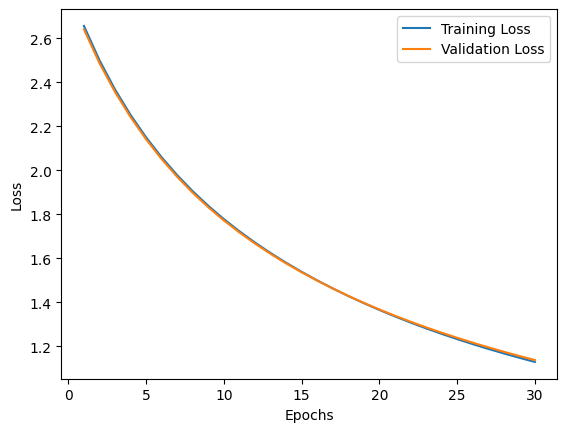

Test Accuracy (tanh): 0.6486
Training model with relu activation function...
Epoch 1/30, Train Loss: 3.9472285950979575 Validation loss: 3.889616462195391
Epoch 2/30, Train Loss: 2.5697359647365445 Validation loss: 2.544177332838188
Epoch 3/30, Train Loss: 2.024043052322761 Validation loss: 2.0203630161620545
Epoch 4/30, Train Loss: 1.7284070777927958 Validation loss: 1.7323569102700718
Epoch 5/30, Train Loss: 1.539142019461335 Validation loss: 1.5465504007022355
Epoch 6/30, Train Loss: 1.4044330477757254 Validation loss: 1.4159972959486495
Epoch 7/30, Train Loss: 1.3011244907328436 Validation loss: 1.3148202709601289
Epoch 8/30, Train Loss: 1.2185340410418062 Validation loss: 1.2329778987578903
Epoch 9/30, Train Loss: 1.1510573378431088 Validation loss: 1.165707834042112
Epoch 10/30, Train Loss: 1.0946590225035882 Validation loss: 1.1094837178368722
Epoch 11/30, Train Loss: 1.0462483357774244 Validation loss: 1.0611393298524794
Epoch 12/30, Train Loss: 1.0039742830091296 Validation lo

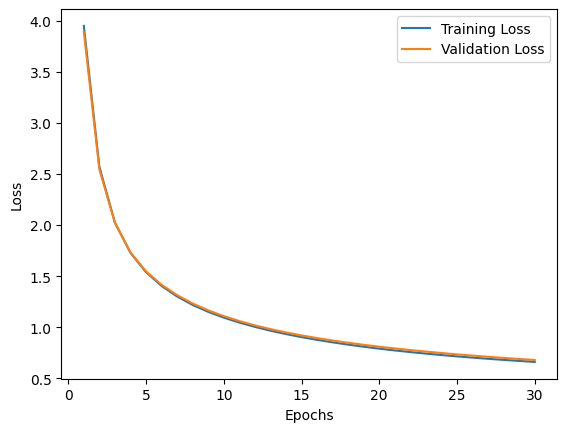

Test Accuracy (relu): 0.7972
Training model with leaky_relu activation function...
Epoch 1/30, Train Loss: 2.6084715954834685 Validation loss: 2.6439374705593957
Epoch 2/30, Train Loss: 2.249284733225831 Validation loss: 2.2775276352531226
Epoch 3/30, Train Loss: 2.1191473597312025 Validation loss: 2.143447087495409
Epoch 4/30, Train Loss: 2.0213048733951884 Validation loss: 2.0428739129981217
Epoch 5/30, Train Loss: 1.9359847182159602 Validation loss: 1.957420915415328
Epoch 6/30, Train Loss: 1.8559503980687484 Validation loss: 1.877976736057266
Epoch 7/30, Train Loss: 1.782941697437763 Validation loss: 1.8048576018414693
Epoch 8/30, Train Loss: 1.7148785140137337 Validation loss: 1.7373296902486979
Epoch 9/30, Train Loss: 1.6508735569672217 Validation loss: 1.6741848642748633
Epoch 10/30, Train Loss: 1.590931837636116 Validation loss: 1.614615649067502
Epoch 11/30, Train Loss: 1.5345311143953444 Validation loss: 1.5578985392292097
Epoch 12/30, Train Loss: 1.4827615928097706 Validatio

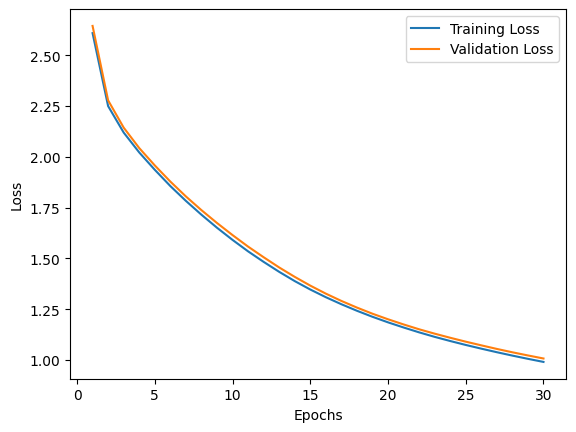

Test Accuracy (leaky_relu): 0.676
Training model with linear activation function...
Epoch 1/30, Train Loss: 3.0974917317904294 Validation loss: 3.1362888283485058
Epoch 2/30, Train Loss: 2.4724097972281647 Validation loss: 2.526645729717757
Epoch 3/30, Train Loss: 2.1706773301401845 Validation loss: 2.2358634421680703
Epoch 4/30, Train Loss: 1.970319015714981 Validation loss: 2.044947895282471
Epoch 5/30, Train Loss: 1.7914416597047111 Validation loss: 1.8730439681896751
Epoch 6/30, Train Loss: 1.6353662895838883 Validation loss: 1.7187313863413798
Epoch 7/30, Train Loss: 1.5064992079867527 Validation loss: 1.5874547826263152
Epoch 8/30, Train Loss: 1.3945701170011473 Validation loss: 1.4706852175074188
Epoch 9/30, Train Loss: 1.293680456793153 Validation loss: 1.3657119590457794
Epoch 10/30, Train Loss: 1.2039586793232762 Validation loss: 1.2730245817386145
Epoch 11/30, Train Loss: 1.1235159386298785 Validation loss: 1.1903085395404538
Epoch 12/30, Train Loss: 1.0512419130188313 Valid

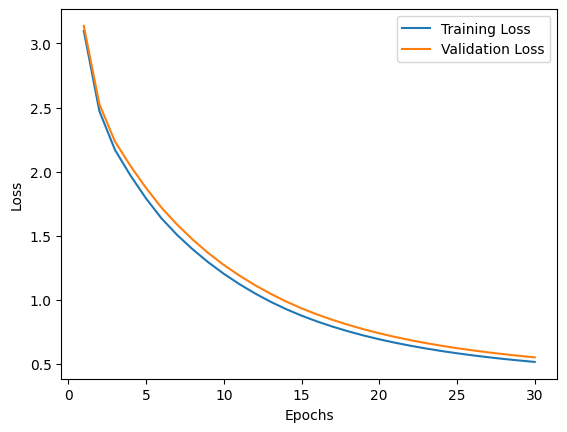

Test Accuracy (linear): 0.8703


In [10]:
from sklearn.preprocessing import StandardScaler
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], -1) /255
X_test = X_test.reshape(X_test.shape[0], -1) /255


X_train, X_valid, Y_train_encoded, Y_valid_encoded = train_test_split(X_train, Y_train, test_size=0.2,random_state=20)
X_train=X_train.T
X_valid=X_valid.T
X_test=X_test.T

activation_functions = [sigmoid, tanh, relu, leaky_relu, linear]
activations=["sigmoid","tanh","relu","leaky_relu","linear"]
activation_gradients = [sigmoid_gradient, tanh_gradient, relu_gradient, leaky_relu_gradient, linear_gradient]

for i, activation in enumerate(activation_functions):
    print(f"Training model with {activation.__name__} activation function...")
    model = NeuralNetwork(N=6, layer_sizes=[784,256,128,64,32,10], lr=0.001,
                          activation=activation, weight_init=random_init,
                          num_epochs=30, batch_size=256,der_activation=activation_gradients[i])

    # model.fit(X_train, Y_train_encoded,X_valid=X_valid, Y_valid=Y_valid_encoded)
    model.fit(X_train, Y_train_encoded,X_valid=X_valid, Y_valid=Y_valid_encoded)
    # Evaluate on the test set
    test_accuracy = model.score(X_test, Y_test)
    print(f"Test Accuracy ({activation.__name__}): {test_accuracy}")